In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 1. LOAD DATA
url = 'https://www.dropbox.com/scl/fi/pm1021x33gr7xxp11hvvb/cleaned_crime_dataset.csv?rlkey=6ifwbgs8z1gs9l9pwglk9aato&st=az9ptobx&dl=1'
df = pd.read_csv(url)

# 2. CLEANING
df = df.drop(columns=['Beat', 'Year'])
df.head()

,Primary Type,Location Description,Arrest,Domestic,District,Ward,Community Area,Month,Day,Hour,DayOfWeek
0,THEFT,RESIDENCE,False,False,4.0,7.0,46.0,1,1,0,Thursday
1,OTHER OFFENSE,RESIDENCE,False,True,9.0,11.0,61.0,3,1,0,Saturday
2,OFFENSE INVOLVING CHILDREN,RESIDENCE,False,False,14.0,35.0,22.0,6,20,11,Sunday
3,THEFT,OTHER,False,False,25.0,31.0,20.0,12,30,20,Thursday
4,THEFT,RESIDENCE,False,False,22.0,34.0,49.0,5,1,1,Thursday


--- MODEL PERFORMANCE ---
Accuracy Score: 49.40%

--- PREDICTION FOR TEST CASE ---
Predicted Crime Type: BATTERY
Priority Level: 1 (High - Violent Crime)
Action: Immediate Dispatch Recommended.


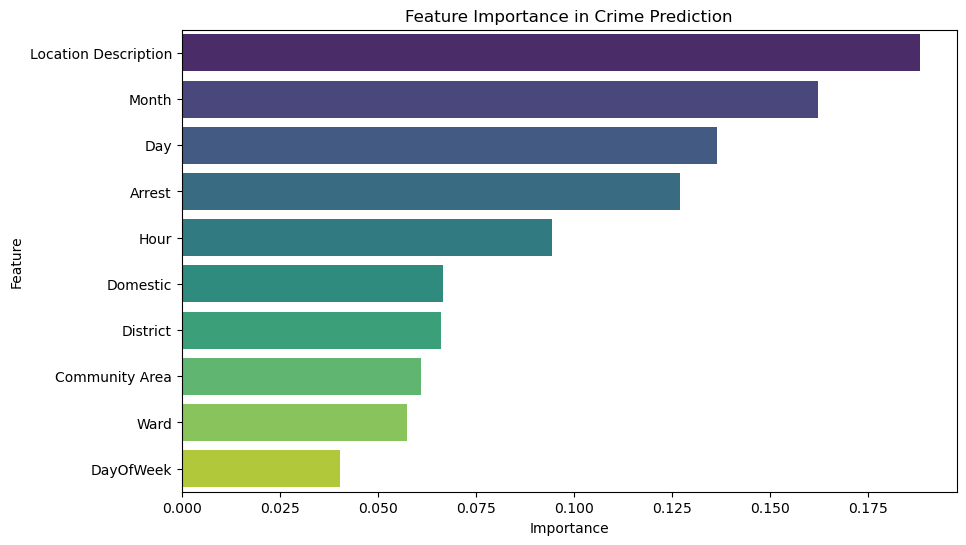

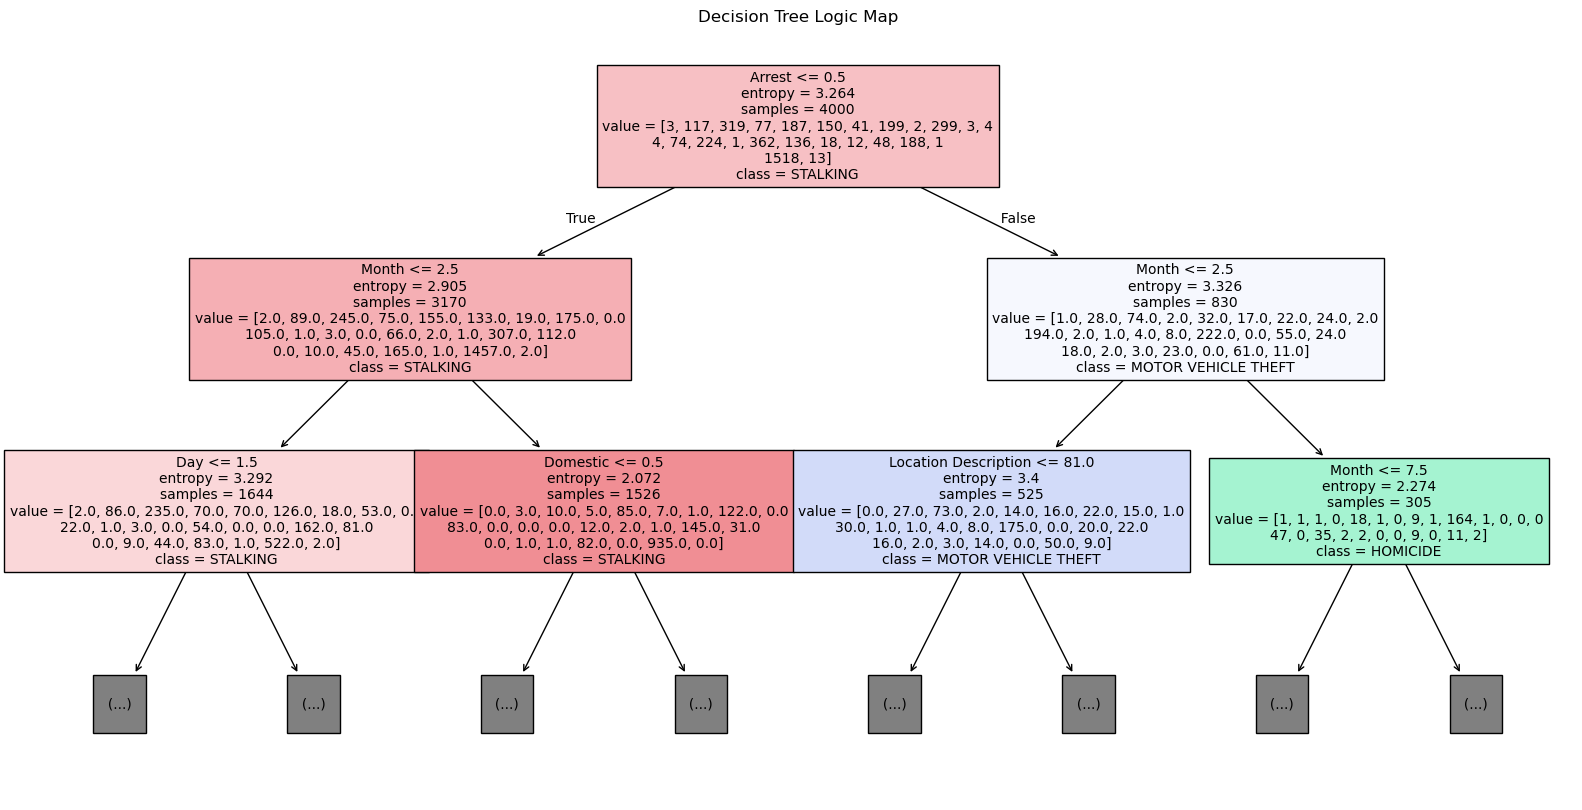

In [2]:
# 3. PREPROCESSING DATA
le_location = LabelEncoder()
df['Location Description'] = le_location.fit_transform(df['Location Description'])

le_day = LabelEncoder()
df['DayOfWeek'] = le_day.fit_transform(df['DayOfWeek'])

le_type = LabelEncoder()
df['Primary Type'] = le_type.fit_transform(df['Primary Type'])

df['Arrest'] = df['Arrest'].astype(int)
df['Domestic'] = df['Domestic'].astype(int)

# 4. DEFINE FEATURES AND TARGET
X = df.drop('Primary Type', axis=1)
y = df['Primary Type']

# 5. SPLIT DATA
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. TRAIN THE MODEL 
model = DecisionTreeClassifier(criterion='entropy', max_depth=10, random_state=42)
model.fit(X_train, y_train)

# 7. EVALUATE & PREDICT
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

# --- TEST ARRAYS (Uncomment one to test) ---
# Example 1: High Priority (Violent/Domestic)
example_data = [[2, 1, 1, 3, 5, 25, 1, 1, 22, 6]] 
# Example 2: Medium Priority (Theft)
# example_data = [[12, 0, 0, 1, 42, 8, 7, 15, 14, 2]]

Test_Prediction = pd.DataFrame(example_data, columns=X.columns)
Result = model.predict(Test_Prediction)

# Convert numeric result back to text
Prediction_made = le_type.inverse_transform(Result)[0]

print(f"--- MODEL PERFORMANCE ---")
print(f"Accuracy Score: {accuracy * 100:.2f}%")
print(f"\n--- PREDICTION FOR TEST CASE ---")
print(f"Predicted Crime Type: {Prediction_made}")

# 8. IF/ELSE PRIORITY LOGIC
if Prediction_made in ['HOMICIDE', 'ROBBERY', 'ASSAULT', 'BATTERY']:
    print("Priority Level: 1 (High - Violent Crime)")
    print("Action: Immediate Dispatch Recommended.")
elif Prediction_made in ['THEFT', 'BURGLARY', 'MOTOR VEHICLE THEFT']:
    print("Priority Level: 2 (Medium - Property Crime)")
    print("Action: Assign Investigator.")
elif Prediction_made == 'DECEPTIVE PRACTICE':
    print("Priority Level: 3 (Low - Financial/Fraud)")
    print("Action: File Electronic Report.")
else:
    print("Priority Level: 4 (Standard)")
    print("Action: Routine Processing.")

# 9. VISUALIZE FEATURE IMPORTANCE
importances = pd.DataFrame({'Feature': X.columns, 'Importance': model.feature_importances_})
importances = importances.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importances, hue='Feature', palette='viridis', legend=False)
plt.title('Feature Importance in Crime Prediction')
plt.show()

# 10. VISUALIZE THE TREE
plt.figure(figsize=(20,10))
tree.plot_tree(model, feature_names=X.columns, class_names=list(le_type.classes_), filled=True, max_depth=2, fontsize=10)
plt.title("Decision Tree Logic Map")
plt.show()